In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Rayo Vallecano"
away= "Espanyol"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
24,Rayo Vallecano,Villarreal,2025-02-22,L,H,0,1,-1,0,0,...,0.5,0.9,-0.6,-0.6,-0.5,0.06,0,1.1,0.21,0.1
25,Rayo Vallecano,Sevilla,2025-03-01,D,H,1,1,0,1,0,...,2.8,2.2,-1.8,-1.8,-1.8,0.14,0,1.3,0.31,0.3
26,Rayo Vallecano,Real Madrid,2025-03-09,L,A,1,2,-1,1,0,...,0.6,0.7,0.0,0.0,0.4,0.05,0,1.6,0.31,-0.4
27,Rayo Vallecano,Real Sociedad,2025-03-16,D,H,2,2,0,2,0,...,0.4,0.5,1.4,1.4,1.6,0.06,1,1.0,0.24,-1.0
28,Rayo Vallecano,Alavés,2025-03-29,W,A,2,0,2,2,0,...,0.4,0.4,1.4,1.4,0.6,0.05,1,1.3,0.17,1.3


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
24,Villarreal,Rayo Vallecano,2025-02-22,W,A,1,0,1,1,0,...,0.5,0.6,0.4,0.4,0.5,0.06,0,0.8,0.16,0.8
25,Sevilla,Rayo Vallecano,2025-03-01,D,A,1,1,0,1,0,...,0.6,0.3,0.4,0.4,0.4,0.06,0,3.0,0.38,2.0
26,Real Madrid,Rayo Vallecano,2025-03-09,W,H,2,1,1,2,0,...,0.8,0.6,0.5,0.5,0.2,0.16,0,0.5,0.08,-0.5
27,Real Sociedad,Rayo Vallecano,2025-03-16,D,A,2,2,0,2,0,...,0.3,0.5,1.4,1.4,0.7,0.07,1,0.8,0.16,-1.2
28,Alavés,Rayo Vallecano,2025-03-29,L,H,0,2,-2,0,0,...,0.5,0.8,-1.5,-0.7,-0.5,0.06,0,1.2,0.24,-0.8


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
23,Espanyol,Athletic Club,2025-02-16,D,H,1,1,0,1,0,...,0.2,0.2,0.2,0.2,-0.2,0.07,0,0.5,0.11,-0.5
24,Espanyol,Alavés,2025-02-22,W,A,1,0,1,1,0,...,0.3,0.5,0.6,0.6,0.7,0.05,0,1.6,0.39,1.6
25,Espanyol,Girona,2025-03-10,D,H,1,1,0,1,0,...,0.2,0.2,0.8,0.8,0.8,0.03,0,1.0,0.06,0.0
26,Espanyol,Mallorca,2025-03-15,L,A,1,2,-1,0,0,...,0.2,0.1,-0.2,-0.2,-0.2,0.10,0,2.8,0.18,0.8
27,Espanyol,Atlético Madrid,2025-03-29,D,H,1,1,0,0,1,...,0.1,0.4,0.0,-0.2,-0.1,0.02,0,0.1,0.05,-0.9


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
23,Athletic Club,Espanyol,2025-02-16,D,A,1,1,0,1,0,...,0.6,0.6,0.0,0.0,0.4,0.08,0,0.6,0.14,-0.4
24,Alavés,Espanyol,2025-02-22,L,H,0,1,-1,0,0,...,1.3,1.1,-1.8,-1.8,-1.3,0.12,2,0.4,0.22,-0.6
25,Girona,Espanyol,2025-03-10,D,A,1,1,0,0,1,...,0.5,1.2,-0.6,-0.8,-0.5,0.05,2,0.4,0.09,-0.6
26,Mallorca,Espanyol,2025-03-15,W,H,2,1,1,1,1,...,1.1,1.2,-0.7,-0.1,-0.1,0.06,0,0.0,NaN,0.0
27,Atlético Madrid,Espanyol,2025-03-29,D,A,1,1,0,1,0,...,0.7,1.0,0.2,0.2,-0.7,0.06,1,1.0,0.00,0.0


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'G-PK', 'PK', 'PKatt', 'PKm', 'Poss', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
24,0,0,0,50,0,28,12,42.9,15,53.6,...,0.1,0.1,0.5,0.9,-0.6,-0.6,-0.5,0.06,0,0
25,1,0,0,64,0,11,2,18.2,9,81.8,...,2.2,2.2,2.8,2.2,-1.8,-1.8,-1.8,0.14,0,1
26,1,0,0,54,0,21,10,47.6,9,42.9,...,-0.5,-0.5,0.6,0.7,0.0,0.0,0.4,0.05,0,1
27,2,0,0,55,0,21,6,28.6,12,57.1,...,0.0,0.0,0.4,0.5,1.4,1.4,1.6,0.06,1,2
28,2,0,0,45,0,19,8,42.1,9,47.4,...,-0.9,-0.1,0.4,0.4,1.4,1.4,0.6,0.05,1,2


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
24,1,0,0,50,0,11,6,54.5,4,36.4,...,-0.1,-0.1,0.5,0.6,0.4,0.4,0.5,0.06,0,1
25,1,0,0,36,0,19,11,57.9,7,36.8,...,-2.2,-2.2,0.6,0.3,0.4,0.4,0.4,0.06,0,1
26,2,0,0,46,0,21,13,61.9,6,28.6,...,0.5,0.5,0.8,0.6,0.5,0.5,0.2,0.16,0,2
27,2,0,0,45,0,25,15,60.0,8,32.0,...,0.0,0.0,0.3,0.5,1.4,1.4,0.7,0.07,1,2
28,0,0,1,55,1,18,6,33.3,10,55.6,...,0.9,0.1,0.5,0.8,-1.5,-0.7,-0.5,0.06,0,0


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
23,1,0,0,39,0,16,5,31.3,9,56.3,...,-0.2,-0.2,0.2,0.2,0.2,0.2,-0.2,0.07,0,1
24,1,0,0,38,0,22,10,45.5,9,40.9,...,-1.3,-1.3,0.3,0.5,0.6,0.6,0.7,0.05,0,1
25,1,0,0,33,0,19,8,42.1,10,52.6,...,-1.3,-0.5,0.2,0.2,0.8,0.8,0.8,0.03,0,1
26,0,0,0,38,0,12,5,41.7,6,50.0,...,-2.5,-0.9,0.2,0.1,-0.2,-0.2,-0.2,0.10,0,1
27,0,1,0,39,1,16,8,50.0,7,43.8,...,0.1,-0.7,0.1,0.4,0.0,-0.2,-0.1,0.02,0,1


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
23,1,0,0,61,0,24,4,16.7,16,66.7,...,0.2,0.2,0.6,0.6,0.0,0.0,0.4,0.08,0,1
24,0,0,0,62,0,18,8,44.4,9,50.0,...,1.3,1.3,1.3,1.1,-1.8,-1.8,-1.3,0.12,2,0
25,0,1,0,67,1,20,9,45.0,8,40.0,...,1.3,0.5,0.5,1.2,-0.6,-0.8,-0.5,0.05,2,1
26,1,1,1,62,2,17,5,29.4,7,41.2,...,2.5,0.9,1.1,1.2,-0.7,-0.1,-0.1,0.06,0,2
27,1,0,0,61,0,11,7,63.6,3,27.3,...,-0.1,0.7,0.7,1.0,0.2,0.2,-0.7,0.06,1,1


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
24,18,1,5.6,0,2,17.6,0,NaN,0,1,...,2,12,13,21,30,1,1.1,0.21,0.1,1
25,14,0,0.0,0,0,4.0,0,NaN,0,0,...,4,10,6,20,25,0,1.3,0.31,0.3,1
26,5,0,0.0,0,2,16.6,0,NaN,0,0,...,2,6,4,20,6,1,1.6,0.31,-0.4,2
27,11,1,9.1,0,0,9.3,0,NaN,0,1,...,2,8,10,25,37,0,1.0,0.24,-1.0,2
28,26,4,15.4,1,0,4.2,1,100.0,0,0,...,2,7,6,24,44,0,1.3,0.17,1.3,0


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
24,21,1,4.8,0,0,5.0,0,NaN,0,0,...,2,7,10,34,27,0,0.8,0.16,0.8,0
25,18,0,0.0,0,0,14.0,0,NaN,0,0,...,4,12,7,25,47,0,3.0,0.38,2.0,1
26,13,1,7.7,0,4,19.3,0,NaN,0,0,...,6,6,14,35,10,2,0.5,0.08,-0.5,1
27,18,3,16.7,0,3,11.8,0,NaN,0,0,...,2,6,7,27,37,0,0.8,0.16,-1.2,2
28,8,0,0.0,0,1,14.3,0,NaN,0,1,...,3,4,10,34,21,1,1.2,0.24,-0.8,2


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,16,0,0.0,0,2,16.8,0,NaN,0,0,...,5,7,6,18,15,0,0.1,0.14,-0.9,1
1,14,2,14.3,0,3,16.7,0,NaN,0,0,...,2,6,7,25,23,0,0.5,0.18,-0.5,1
2,20,0,0.0,0,0,11.5,0,NaN,0,0,...,8,8,7,21,41,1,1.4,0.19,1.4,0
3,21,1,4.8,0,1,13.7,0,NaN,0,0,...,5,7,11,29,37,0,0.6,0.11,-0.4,1
4,32,3,9.4,0,1,7.5,0,NaN,0,1,...,6,11,4,21,48,2,2.7,0.51,0.7,2


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,13,1,7.7,0,3,23.3,0,NaN,0,0,...,3,12,8,17,21,0,0.8,0.41,0.8,0
1,14,0,0.0,0,1,19.0,0,NaN,0,0,...,4,8,8,19,19,1,0.5,0.15,0.5,0
2,14,0,0.0,0,2,20.7,0,NaN,0,0,...,0,6,5,15,15,0,0.0,0.03,0.0,0
3,11,0,0.0,0,1,13.0,0,NaN,0,0,...,3,7,9,24,13,0,1.6,0.61,-0.4,2
4,8,1,12.5,1,0,11.3,0,0.0,0,0,...,1,2,11,27,7,0,2.4,0.48,-0.6,3


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
24,14,11,56.0,1,1,0,15,11,51
25,13,4,76.5,1,0,0,14,8,45
26,1,7,12.5,1,0,0,17,12,46
27,23,14,62.2,3,0,0,16,9,61
28,24,23,51.1,5,0,0,12,14,53


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
24,11,14,44.0,4,0,0,12,14,40
25,4,13,23.5,0,0,0,9,14,50
26,7,1,87.5,3,0,0,12,17,38
27,14,23,37.8,2,0,0,9,14,51
28,23,24,48.9,3,0,0,14,11,59


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
23,10,14,41.7,1,0,0,12,7,42
24,20,29,40.8,2,0,0,17,13,41
25,9,14,39.1,3,0,0,11,12,27
26,16,14,53.3,2,0,0,12,9,27
27,10,10,50.0,2,0,0,12,14,39


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
23,14,10,58.3,1,0,0,8,12,48
24,29,20,59.2,2,0,0,13,17,48
25,14,9,60.9,3,0,0,13,11,37
26,14,16,46.7,0,0,0,10,12,46
27,10,10,50.0,1,0,0,14,12,44


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
24,0,0,0,50,0,28,12,42.9,15,53.6,...,-0.975,0.403113,-0.800,0.336650,0.1275,0.015000,0.50,0.57735,1.0,0.816497
25,1,0,0,64,0,11,2,18.2,9,81.8,...,-1.025,0.309570,-0.825,0.298608,0.1075,0.034034,0.50,0.57735,0.5,0.577350
26,1,0,0,54,0,21,10,47.6,9,42.9,...,-1.175,0.505800,-0.975,0.573730,0.1075,0.034034,0.25,0.50000,0.5,0.577350
27,2,0,0,55,0,21,6,28.6,12,57.1,...,-0.850,0.754983,-0.650,0.903696,0.0900,0.042426,0.00,0.00000,0.5,0.577350
28,2,0,0,45,0,19,8,42.1,9,47.4,...,-0.250,1.330413,-0.075,1.436141,0.0775,0.041932,0.25,0.50000,1.0,0.816497


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
24,1,0,0,50,0,11,6,54.5,4,36.4,...,-0.550,0.718795,-2.500000e-01,0.655744,0.0725,0.035940,0.50,0.57735,0.50,0.57735
25,1,0,0,36,0,19,11,57.9,7,36.8,...,-0.450,0.838650,-2.500000e-01,0.655744,0.0675,0.035940,0.25,0.50000,0.50,0.57735
26,2,0,0,46,0,21,13,61.9,6,28.6,...,-0.300,0.945163,-1.000000e-01,0.734847,0.0725,0.032016,0.25,0.50000,0.75,0.50000
27,2,0,0,45,0,25,15,60.0,8,32.0,...,-0.075,1.017759,-9.714451e-17,0.743864,0.1000,0.048990,0.00,0.00000,1.25,0.50000
28,0,0,1,55,1,18,6,33.3,10,55.6,...,0.675,0.485627,4.500000e-01,0.208167,0.0875,0.048563,0.25,0.50000,1.50,0.57735


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
23,23,2,8.7,0,0,6.0,0,0.0,0,1,...,0.50,0.57735,1.000,0.503322,0.2600,0.206074,6.938894e-17,0.621825,1.00,0.816497
24,22,2,9.1,0,0,10.4,0,0.0,0,0,...,0.50,0.57735,0.900,0.565685,0.2300,0.220151,-1.000000e-01,0.673300,1.00,0.816497
25,25,3,12.0,1,0,8.5,0,0.0,0,0,...,0.25,0.50000,1.175,0.573730,0.2975,0.216545,4.250000e-01,0.997914,0.75,0.957427
26,21,3,14.3,2,1,9.7,1,50.0,0,0,...,0.25,0.50000,1.200,0.559762,0.2800,0.236502,2.000000e-01,0.955685,1.00,0.816497
27,8,0,0.0,0,0,6.0,0,0.0,0,0,...,0.25,0.50000,1.475,0.991211,0.1850,0.145258,4.750000e-01,0.921502,1.00,0.816497


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
23,10,0,0.0,0,3,23.2,0,0.0,0,0,...,0.75,0.500000,0.90,0.346410,0.3575,0.326331,-0.35,0.191485,1.25,0.5
24,10,1,10.0,0,1,15.5,0,0.0,0,0,...,1.00,0.816497,0.70,0.115470,0.3050,0.344335,-0.30,0.115470,1.00,0.0
25,9,0,0.0,0,1,19.3,0,0.0,0,0,...,0.75,0.957427,0.60,0.163299,0.1625,0.124466,-0.40,0.163299,1.00,0.0
26,6,0,0.0,0,2,24.5,0,0.0,0,0,...,0.50,1.000000,0.55,0.191485,0.1125,0.092150,-0.45,0.191485,1.00,0.0
27,15,1,6.7,1,0,8.0,0,0.0,0,0,...,0.50,1.000000,0.35,0.251661,0.1500,0.065574,-0.40,0.282843,1.00,0.0


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
23,1,0,0,39,0,16,5,31.3,9,56.3,...,0.475,0.478714,0.425,0.684957,0.0700,0.039158,1.00,1.414214,1.25,0.5
24,1,0,0,38,0,22,10,45.5,9,40.9,...,0.275,0.330404,0.075,0.485627,0.0675,0.038622,0.25,0.500000,1.00,0.0
25,1,0,0,33,0,19,8,42.1,10,52.6,...,0.350,0.369685,0.300,0.522813,0.0500,0.016330,0.00,0.000000,1.00,0.0
26,0,0,0,38,0,12,5,41.7,6,50.0,...,0.375,0.403113,0.300,0.522813,0.0450,0.019149,0.00,0.000000,1.00,0.0
27,0,1,0,39,1,16,8,50.0,7,43.8,...,0.350,0.443471,0.275,0.550000,0.0625,0.029861,0.00,0.000000,1.00,0.0


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
23,1,0,0,61,0,24,4,16.7,16,66.7,...,-0.350,0.675771,-0.575,0.623832,0.0875,0.038622,1.50,0.577350,1.00,0.816497
24,0,0,0,62,0,18,8,44.4,9,50.0,...,-0.300,0.697615,-0.175,0.602080,0.0800,0.035590,1.25,0.957427,1.00,0.816497
25,0,1,0,67,1,20,9,45.0,8,40.0,...,-0.700,1.009950,-0.525,0.771902,0.0975,0.033040,1.50,1.000000,0.75,0.957427
26,1,1,1,62,2,17,5,29.4,7,41.2,...,-0.575,0.939415,-0.400,0.707107,0.0950,0.036968,1.50,1.000000,1.00,0.816497
27,1,0,0,61,0,11,7,63.6,3,27.3,...,-0.675,0.830161,-0.375,0.718215,0.0775,0.030957,1.00,1.154701,1.00,0.816497


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
24,18,1,5.6,0,2,17.6,0,0.0,0,1,...,1.00,1.414214,0.925,0.499166,0.1300,0.110454,0.425,0.125831,0.50,0.57735
25,14,0,0.0,0,0,4.0,0,0.0,0,0,...,1.00,1.414214,0.875,0.457347,0.1150,0.086603,0.375,0.206155,0.50,0.57735
26,5,0,0.0,0,2,16.6,0,0.0,0,0,...,1.00,1.414214,1.050,0.450925,0.1925,0.088081,0.300,0.141421,0.75,0.50000
27,11,1,9.1,0,0,9.3,0,0.0,0,1,...,1.25,1.258306,1.350,0.208167,0.2400,0.087178,0.100,0.355903,1.25,0.50000
28,26,4,15.4,1,0,4.2,1,100.0,0,0,...,0.50,0.577350,1.250,0.264575,0.2675,0.050580,-0.250,0.580230,1.50,0.57735


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
24,21,1,4.8,0,0,5.0,0,0.0,0,0,...,1.00,1.414214,1.150,0.506623,0.290,0.146515,0.150,0.506623,1.0,0.816497
25,18,0,0.0,0,0,14.0,0,0.0,0,0,...,0.25,0.500000,0.900,0.270801,0.265,0.161142,0.400,0.522813,0.5,0.577350
26,13,1,7.7,0,4,19.3,0,0.0,0,0,...,0.00,0.000000,1.325,1.117661,0.235,0.103763,0.825,0.939415,0.5,0.577350
27,18,3,16.7,0,3,11.8,0,0.0,0,0,...,0.50,1.000000,1.275,1.158663,0.215,0.127932,0.775,1.021029,0.5,0.577350
28,8,0,0.0,0,1,14.3,0,0.0,0,1,...,0.50,1.000000,1.275,1.158663,0.195,0.128970,0.275,1.417451,1.0,0.816497


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
24,14,11,56.0,1,1,0,15,11,51,10.75,...,0.00,0.0,0.0,0.0,14.50,5.259911,10.00,3.915780,45.25,4.573474
25,13,4,76.5,1,0,0,14,8,45,12.00,...,0.25,0.5,0.0,0.0,13.50,4.434712,10.75,3.685557,47.00,5.228129
26,1,7,12.5,1,0,0,17,12,46,12.25,...,0.25,0.5,0.0,0.0,12.25,2.753785,11.25,2.872281,45.25,4.031129
27,23,14,62.2,3,0,0,16,9,61,8.00,...,0.25,0.5,0.0,0.0,13.75,3.403430,10.50,1.732051,46.25,3.403430
28,24,23,51.1,5,0,0,12,14,53,12.75,...,0.25,0.5,0.0,0.0,15.50,1.290994,10.00,1.825742,50.75,7.320064


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
24,11,14,44.0,4,0,0,12,14,40,11.00,...,0.25,0.5,0.0,0.0,10.50,3.415650,14.25,4.991660,43.75,6.652067
25,4,13,23.5,0,0,0,9,14,50,11.25,...,0.25,0.5,0.0,0.0,11.25,3.304038,13.25,4.349329,44.25,6.130525
26,7,1,87.5,3,0,0,12,17,38,9.75,...,0.00,0.0,0.0,0.0,11.75,2.500000,12.00,2.449490,44.50,6.403124
27,14,23,37.8,2,0,0,9,14,51,8.25,...,0.00,0.0,0.0,0.0,11.00,1.414214,13.50,3.316625,44.50,6.403124
28,23,24,48.9,3,0,0,14,11,59,9.00,...,0.00,0.0,0.0,0.0,10.50,1.732051,14.75,1.500000,44.75,6.701990


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
23,10,14,41.7,1,0,0,12,7,42,15.00,...,0.0,0.0,0.0,0.0,14.50,1.732051,10.25,5.123475,35.75,6.652067
24,20,29,40.8,2,0,0,17,13,41,12.50,...,0.0,0.0,0.0,0.0,14.25,2.061553,8.25,4.112988,36.00,6.928203
25,9,14,39.1,3,0,0,11,12,27,13.50,...,0.0,0.0,0.0,0.0,15.00,2.449490,8.50,4.434712,38.75,5.852350
26,16,14,53.3,2,0,0,12,9,27,14.25,...,0.0,0.0,0.0,0.0,14.25,3.201562,10.75,2.629956,35.00,7.615773
27,10,10,50.0,2,0,0,12,14,39,13.75,...,0.0,0.0,0.0,0.0,13.00,2.708013,10.25,2.753785,34.25,8.381527


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
23,14,10,58.3,1,0,0,8,12,48,14.00,...,0.0,0.0,0.0,0.0,10.75,5.560276,13.75,0.957427,46.00,6.582806
24,29,20,59.2,2,0,0,13,17,48,13.00,...,0.0,0.0,0.0,0.0,8.75,4.349329,13.50,1.290994,47.50,6.027714
25,14,9,60.9,3,0,0,13,11,37,15.50,...,0.0,0.0,0.0,0.0,8.75,4.349329,14.50,2.081666,46.25,4.924429
26,14,16,46.7,0,0,0,10,12,46,17.25,...,0.0,0.0,0.0,0.0,11.25,2.362908,13.75,2.753785,45.75,5.909033
27,10,10,50.0,1,0,0,14,12,44,17.75,...,0.0,0.0,0.0,0.0,11.00,2.449490,13.00,2.708013,44.75,5.251984


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,2,0,0,45,0,19,8,42.1,9,47.4,...,0.5,1.475,0.991211,0.185,0.145258,0.475,0.921502,1.0,0.816497,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,0,34,0,11,6,54.5,5,45.5,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,A,0
1,0,0,0,52,0,17,6,35.3,8,47.1,...,0.0,0.0,8.000000,0.000000,15.0,0.000000,34.000000,0.000000,H,1
2,1,0,0,36,0,11,3,27.3,6,54.5,...,0.0,0.0,11.000000,4.242641,16.5,2.121320,35.000000,1.414214,A,1
3,1,0,0,53,0,16,7,43.8,7,43.8,...,0.0,0.0,10.333333,3.214550,13.0,6.244998,34.666667,1.154701,H,3
4,3,0,0,65,0,16,11,68.8,5,31.3,...,0.0,0.0,11.250000,3.201562,13.5,5.196152,35.250000,1.500000,H,1


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,26,4,15.4,1,0,4.2,1,100.0,0,0,...,0.0,0.0,0.0,13.0,2.708013,10.25,2.753785,34.25,8.381527,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,21,0,0.0,0,0,0.0,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,A,0
1,11,1,9.1,0,0,7.7,0,0.0,0,0,...,0.0,0.0,8.000000,0.000000,15.0,0.000000,34.000000,0.000000,H,2
2,14,0,0.0,0,0,9.8,0,0.0,0,0,...,0.0,0.0,11.000000,4.242641,16.5,2.121320,35.000000,1.414214,A,2
3,11,0,0.0,0,1,13.0,0,0.0,0,0,...,0.0,0.0,10.333333,3.214550,13.0,6.244998,34.666667,1.154701,H,1
4,9,0,0.0,0,1,24.0,0,0.0,0,0,...,0.0,0.0,11.250000,3.201562,13.5,5.196152,35.250000,1.500000,H,1


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,1,0,39,1,16,8,50.0,7,43.8,...,0.0,0.0,0.0,13.0,2.708013,10.25,2.753785,34.25,8.381527,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0.0,0.0,0.0,54.0,0.0,5.0,2.0,40.0,2.0,40.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,H,0.0
1,0.0,0.0,0.0,34.0,0.0,15.0,5.0,33.3,6.0,40.0,...,0.0,0.0,8.000000,0.000000,15.0,0.000000,34.000000,0.000000,A,0.0
2,0.0,0.0,0.0,37.0,0.0,11.0,6.0,54.5,5.0,45.5,...,0.0,0.0,11.000000,4.242641,16.5,2.121320,35.000000,1.414214,H,2.0
3,2.0,0.0,0.0,47.0,0.0,14.0,4.0,28.6,8.0,57.1,...,0.0,0.0,10.333333,3.214550,13.0,6.244998,34.666667,1.154701,H,3.0
4,2.0,1.0,0.0,39.0,1.0,16.0,4.0,25.0,7.0,43.8,...,0.0,0.0,11.250000,3.201562,13.5,5.196152,35.250000,1.500000,A,1.0


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,8,0,0.0,0,0,6.0,0,0.0,0,0,...,0.0,0.0,0.0,13.0,2.708013,10.25,2.753785,34.25,8.381527,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,16.0,0.0,0.0,0.0,2.0,16.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,H,1.0
1,14.0,2.0,14.3,0.0,3.0,16.7,0.0,0.0,0.0,0.0,...,0.0,0.0,8.000000,0.000000,15.0,0.000000,34.000000,0.000000,A,0.0
2,20.0,0.0,0.0,0.0,0.0,11.5,0.0,0.0,0.0,0.0,...,0.0,0.0,11.000000,4.242641,16.5,2.121320,35.000000,1.414214,H,1.0
3,21.0,1.0,4.8,0.0,1.0,13.7,0.0,0.0,0.0,0.0,...,0.0,0.0,10.333333,3.214550,13.0,6.244998,34.666667,1.154701,H,2.0
4,32.0,3.0,9.4,0.0,1.0,7.5,0.0,0.0,0.0,1.0,...,0.0,0.0,11.250000,3.201562,13.5,5.196152,35.250000,1.500000,A,4.0


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

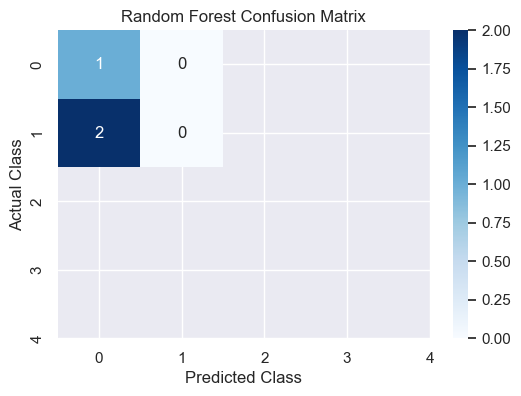

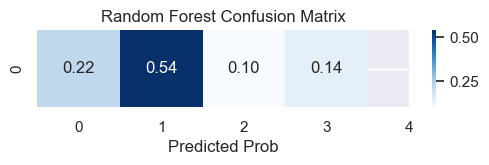

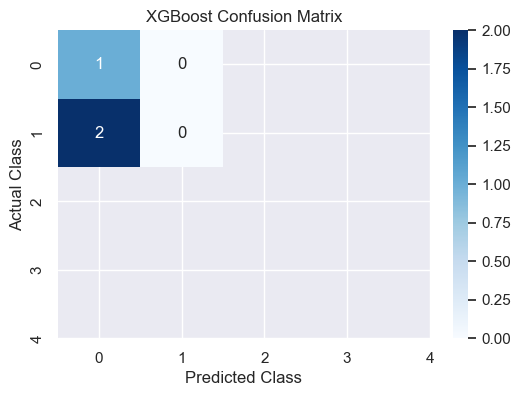

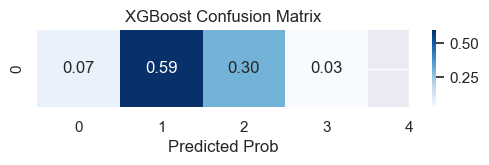

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

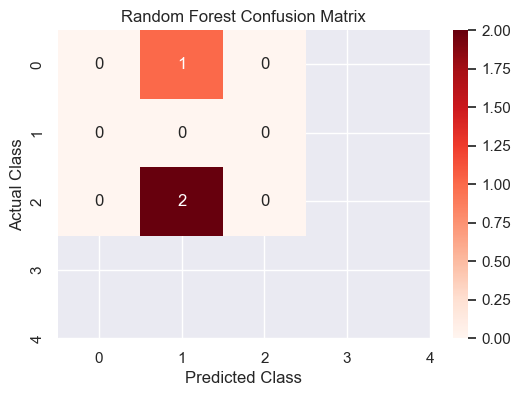

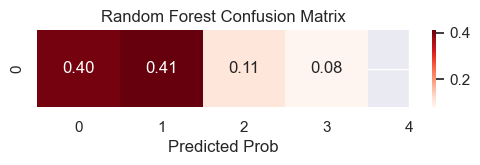

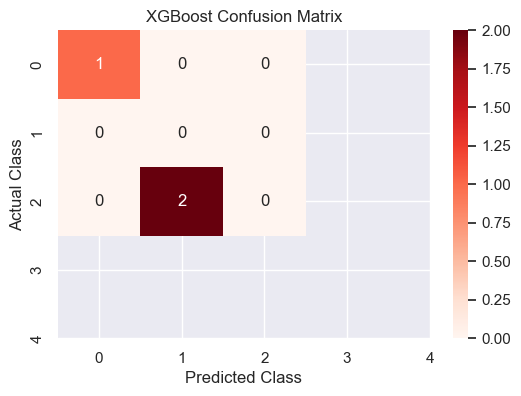

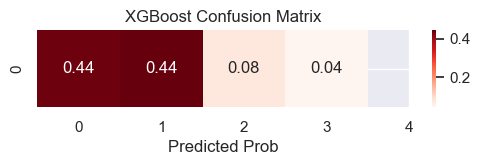

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

ValueError: Found unknown categories [0] in column 0 during transform

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

ValueError: Found unknown categories [0] in column 0 during transform

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

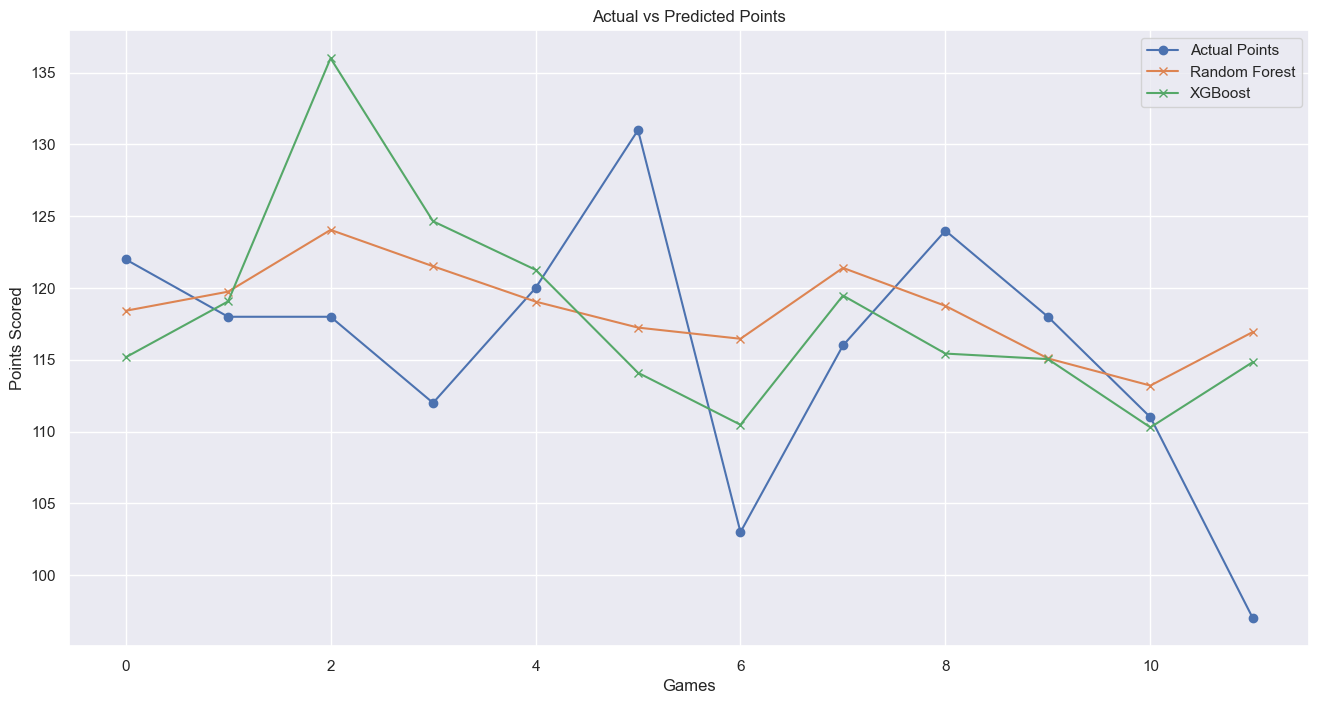

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
